In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

file_path = "LengthOfStay.csv"  
df = pd.read_csv(file_path)

df['rcount'] = df['rcount'].replace('5+', 5).astype(int)

df['gender'] = df['gender'].map({'M': 1, 'F': 0})

numerical_cols = [
    'rcount', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
    'substancedependence', 'psychologicaldisordermajor', 'depress',
    'psychother', 'fibrosisandother', 'malnutrition', 'hemo',
    'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
    'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9',
    
]

df.drop(['vdate', 'discharged', 'facid'], axis=1, inplace=True)

df.to_csv("ProccecedLengthOfStayF.csv", index=False)

print("'ProccecedLengthOfStayF.csv'")


'ProccecedLengthOfStayF.csv'


Top features correlated with length of stay:

lengthofstay                  1.000000
rcount                        0.731423
psychologicaldisordermajor    0.286724
hemo                          0.217696
irondef                       0.193838
psychother                    0.191695
malnutrition                  0.174397
dialysisrenalendstage         0.169695
bloodureanitro                0.148290
substancedependence           0.147886
pneum                         0.135461
depress                       0.121408
asthma                        0.082005
gender                        0.069575
fibrosisandother              0.062131
pulse                         0.006683
secondarydiagnosisnonicd9     0.006540
bmi                           0.000132
glucose                      -0.003447
sodium                       -0.003546
creatinine                   -0.004026
neutrophils                  -0.010658
respiration                  -0.022291
hematocrit                   -0.064016
Name: lengthofstay

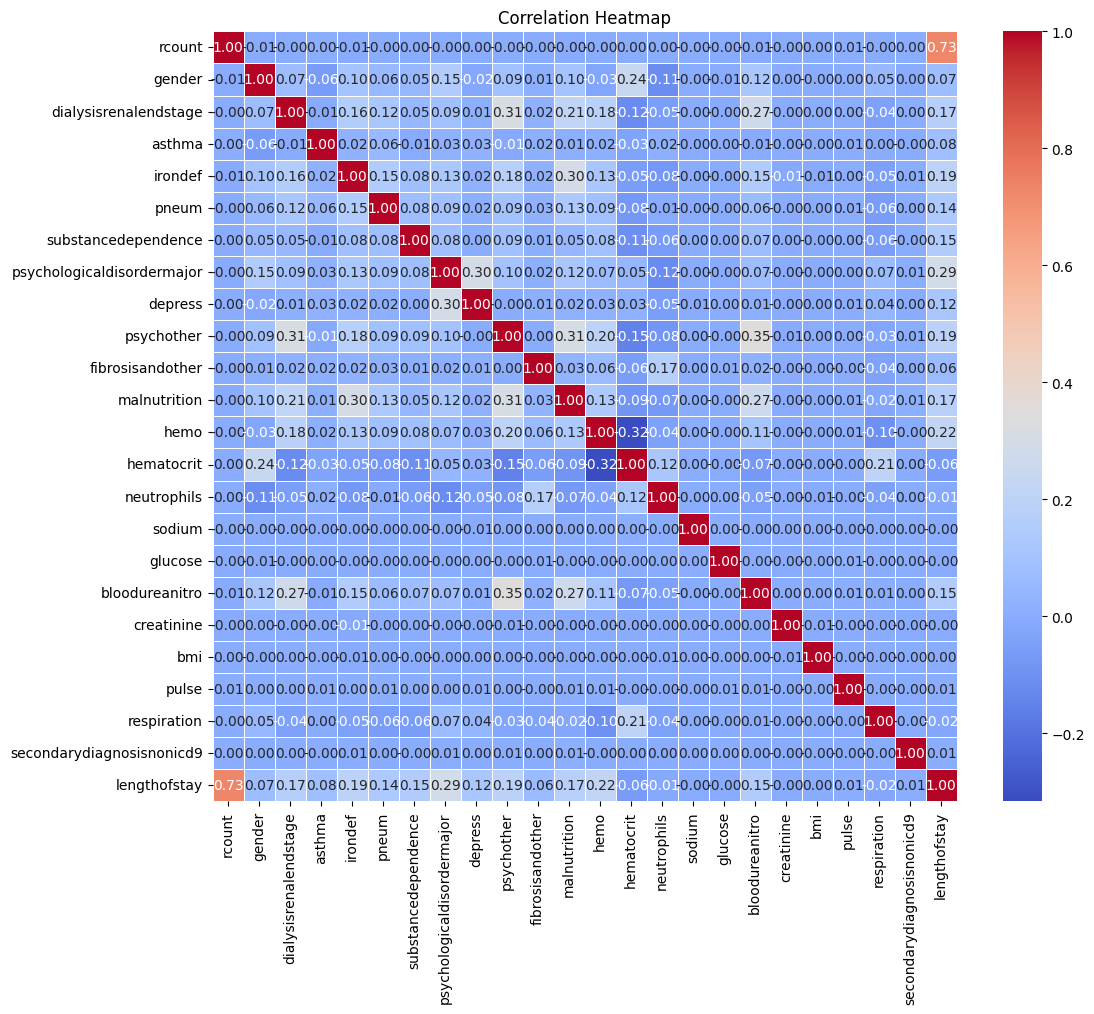

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the processed CSV file
file_path = "ProccecedLengthOfStayF.csv"
df = pd.read_csv(file_path)
df.drop(['eid'], axis=1, inplace=True)
# Compute the correlation matrix
correlation_matrix = df.corr()

# Extract the most correlated features with lengthofstay
correlation_with_target = correlation_matrix['lengthofstay'].sort_values(ascending=False)

# Print the most correlated features with lengthofstay
print("Top features correlated with length of stay:\n")
print(correlation_with_target)

# Plot the heatmap to visualize the correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


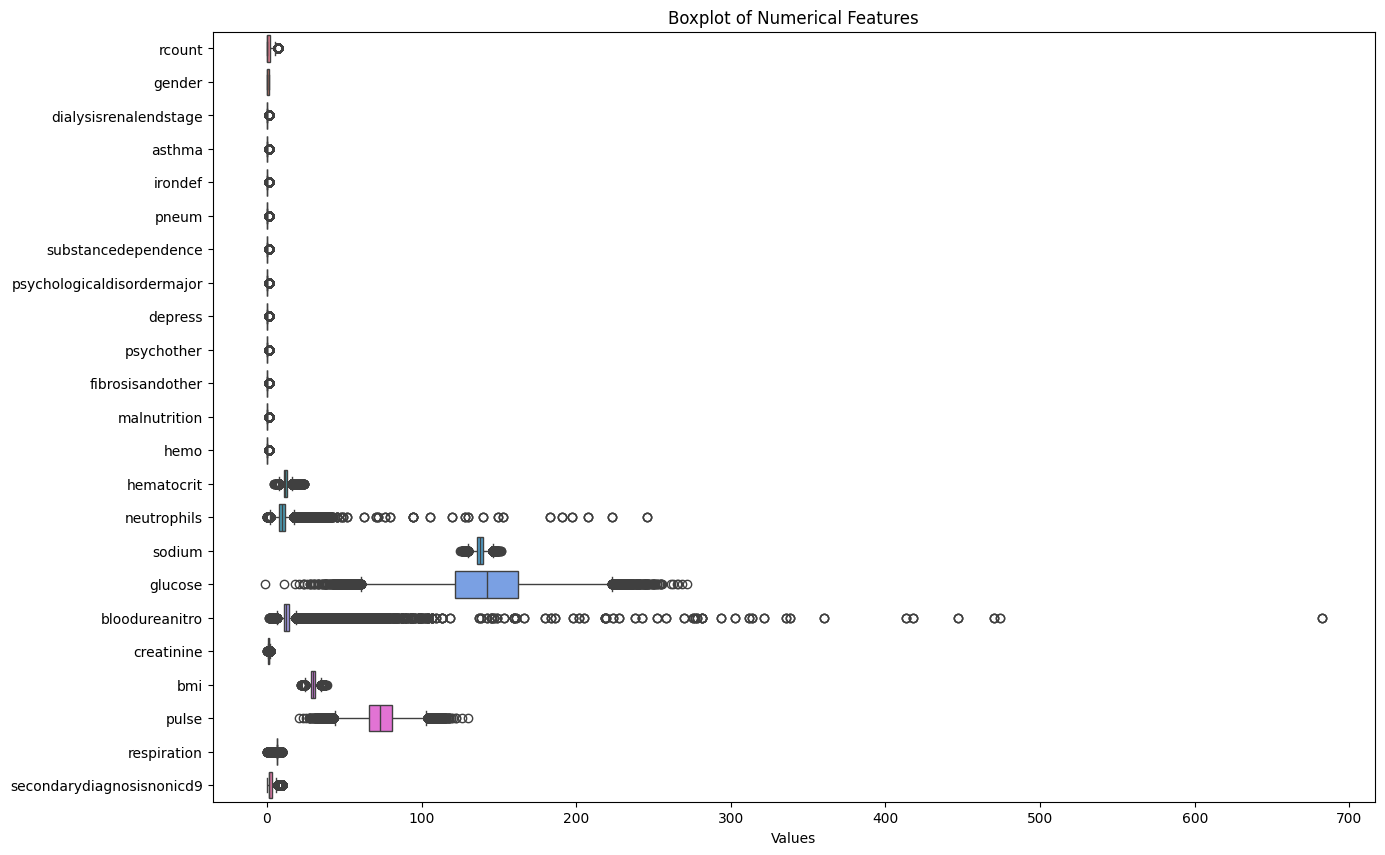

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = [
    'rcount','gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
    'substancedependence', 'psychologicaldisordermajor', 'depress',
    'psychother', 'fibrosisandother', 'malnutrition', 'hemo',
    'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
    'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9',  
    
]

# Create a boxplot for each numerical column
plt.figure(figsize=(15, 10))
sns.boxplot(data=df[numerical_cols], orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.show()


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the data
data = pd.read_csv('ProccecedLengthOfStayF.csv')

# Initialize the Min-Max Scaler
scaler = MinMaxScaler()

# Columns to normalize
columns_to_normalize = ['rcount', 'hematocrit', 'neutrophils', 'sodium', 'glucose','bloodureanitro','creatinine', 'bmi', 'pulse', 'respiration',
                        'secondarydiagnosisnonicd9','lengthofstay']

# Apply Min-Max Scaling
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

# Save the normalized data to a new file
normalized_file_path = 'Normalized_LengthOfStayF.csv'
data.to_csv(normalized_file_path, index=False)

print(f"Normalized data has been saved to ")

Normalized data has been saved to 


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the pre-normalized dataset
file_path = 'Normalized_LengthOfStayF.csv'
data = pd.read_csv(file_path)

# Define features and target
columns_to_use = [
'rcount',                       
'psychologicaldisordermajor',    
'hemo',                          
'irondef',                      
'psychother',                   
'malnutrition',                 
'dialysisrenalendstage',        
'bloodureanitro',                
'substancedependence',           
'pneum',                         
'depress',                      
'asthma',                       
'gender',                        
'fibrosisandother',             
'pulse',                         
'secondarydiagnosisnonicd9',    
'bmi',                           
'glucose',                      
'sodium',                       
'creatinine',                   
'neutrophils',                 
'respiration',                 
'hematocrit', 
]  
target_column = 'lengthofstay'

X = data[columns_to_use]
y = data[target_column]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R^2 Score: {r2}")


Mean Squared Error (MSE): 0.005893971960486415
Mean Absolute Error (MAE): 0.05808103232187701
R^2 Score: 0.7250222673578259


In [14]:
import numpy as np
import pandas as pd

class LogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.iterations):
            # Linear model
            linear_model = np.dot(X, self.weights) + self.bias
            
            # Apply sigmoid activation function
            y_predicted = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        # Linear model
        linear_model = np.dot(X, self.weights) + self.bias

        # Apply sigmoid activation and threshold at 0.5
        y_predicted = self.sigmoid(linear_model)
        return np.where(y_predicted > 0.5, 1, 0)

    def predict_proba(self, X):
        # Linear model
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

# Example usage
if __name__ == "__main__":
    # Load dataset
    file_path = "Normalized_LengthOfStay1.csv"
    data = pd.read_csv(file_path)

    # Define features (X) and target (y)
    X = data.drop(columns=["lengthofstay"]).values
    y = (data["lengthofstay"] > 0.2).astype(int).values  # Binary target: 1 if lengthofstay > 0.2, else 0

    # Split data into training and testing sets
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create and train the model
    model = LogisticRegression(learning_rate=0.01, iterations=1000)
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    # Evaluate the model
    from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score

    accuracy = accuracy_score(y_test, predictions)
    mae = mean_absolute_error(y_test, probabilities)
    mse = mean_squared_error(y_test, probabilities)
    r2 = r2_score(y_test, probabilities)

    print("Mean Absolute Error (MAE):", mae)
    print("Mean Squared Error (MSE):", mse)
    print("R² Score:", r2)


Mean Absolute Error (MAE): 0.41858087160613394
Mean Squared Error (MSE): 0.18660676862527004
R² Score: 0.20927082922830276


In [15]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
ridge_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.best_params_['alpha']
best_alpha_ridge = ridge_cv.best_params_['alpha']

lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_train, y_train)
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train, y_train)

y_pred_lasso = lasso_best.predict(X_test)
y_pred_ridge = ridge_best.predict(X_test)

print("Lasso Regression:")
print(f"Best Alpha: {best_alpha_lasso}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_lasso)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_lasso)}")
print(f"R² Score: {r2_score(y_test, y_pred_lasso)}\n")

print("Ridge Regression:")
print(f"Best Alpha: {best_alpha_ridge}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred_ridge)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_ridge)}")
print(f"R² Score: {r2_score(y_test, y_pred_ridge)}")


Lasso Regression:
Best Alpha: 0.001
Mean Absolute Error (MAE): 0.24079517624892424
Mean Squared Error (MSE): 0.10226161142610844
R² Score: 0.5666757438626258

Ridge Regression:
Best Alpha: 1
Mean Absolute Error (MAE): 0.23703688524375272
Mean Squared Error (MSE): 0.10137979940396821
R² Score: 0.5704123419194931


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


important_features = [
    'rcount', 
    'psychologicaldisordermajor', 
    
]


additional_features = [
'hemo',                          
'irondef',                      
'psychother',                   
'malnutrition',                 
'dialysisrenalendstage',        
'bloodureanitro',                
'substancedependence',           
'pneum',                         
'depress',                      
'asthma',                       
'gender',                        
'fibrosisandother',             
'pulse',                         
'secondarydiagnosisnonicd9',    
'bmi',                           
'glucose',                      
'sodium',                       
'creatinine',                   
'neutrophils',                 
'respiration',                 
'hematocrit',
  ]  

results = []

for feature in additional_features:
    print(f"Adding feature: {feature}")
    
    important_features.append(feature)
    X_reduced = data[important_features]
    y = data['lengthofstay']
    
    X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    results.append({
        'Feature Added': feature,
        'MAE Train': mae_train,
        'MSE Train': mse_train,
        'R² Train': r2_train,
        'MAE Test': mae_test,
        'MSE Test': mse_test,
        'R² Test': r2_test
    })
    
    print("Train Set Metrics:")
    print(f"Mean Absolute Error (MAE): {mae_train}")
    print(f"Mean Squared Error (MSE): {mse_train}")
    print(f"R² Score: {r2_train}\n")
    
    print("Test Set Metrics:")
    print(f"Mean Absolute Error (MAE): {mae_test}")
    print(f"Mean Squared Error (MSE): {mse_test}")
    print(f"R² Score: {r2_test}\n")

import pandas as pd
results_df = pd.DataFrame(results)
print("Summary of Results:")
print(results_df)


Adding feature: hemo
Train Set Metrics:
Mean Absolute Error (MAE): 0.06286706530104252
Mean Squared Error (MSE): 0.006648525176455215
R² Score: 0.6956303997624871

Test Set Metrics:
Mean Absolute Error (MAE): 0.06243059209601072
Mean Squared Error (MSE): 0.006495085600079173
R² Score: 0.6969778744113315

Adding feature: irondef
Train Set Metrics:
Mean Absolute Error (MAE): 0.059320763429431905
Mean Squared Error (MSE): 0.0060366986659751536
R² Score: 0.7236398282397988

Test Set Metrics:
Mean Absolute Error (MAE): 0.059051066380932105
Mean Squared Error (MSE): 0.005921212570304694
R² Score: 0.7237513822613515

Adding feature: psychother
Train Set Metrics:
Mean Absolute Error (MAE): 0.05802657384375377
Mean Squared Error (MSE): 0.005686096430873941
R² Score: 0.7396904047673634

Test Set Metrics:
Mean Absolute Error (MAE): 0.057760401360909874
Mean Squared Error (MSE): 0.00557412089962236
R² Score: 0.7399446185480296

Adding feature: malnutrition
Train Set Metrics:
Mean Absolute Error (M

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Load data
file_path = "Normalized_LengthOfStayF.csv"
df = pd.read_csv(file_path)

# Define features and target
X = df.drop(['lengthofstay', 'gender', 'secondarydiagnosisnonicd9'], axis=1)
y = df['lengthofstay']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize RandomForestRegressor with best hyperparameters
best_model = RandomForestRegressor(
    max_depth=None,
    max_features=None,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

# Train the model
best_model.fit(X_train, y_train)

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics for training set
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Metrics for testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print results
print("\nPerformance on Training Set:")
print(f"  MAE: {mae_train}")
print(f"  MSE: {mse_train}")
print(f"  R²: {r2_train}")

print("\nPerformance on Testing Set:")
print(f"  MAE: {mae_test}")
print(f"  MSE: {mse_test}")
print(f"  R²: {r2_test}")



Performance on Training Set:
  MAE: 0.013188314815287734
  MSE: 0.0005026510239008029
  R²: 0.9769886272303726

Performance on Testing Set:
  MAE: 0.023819985594395004
  MSE: 0.0015442373857923965
  R²: 0.927955053425224


In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Load data
file_path = "Normalized_LengthOfStayF.csv"
df = pd.read_csv(file_path)

# Define features and target
X = df.drop(['lengthofstay', 'gender', 'secondarydiagnosisnonicd9'], axis=1)
y = df['lengthofstay']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 150, 200],         # Number of trees
    'max_depth': [10, 20, None],             # Tree depth
    'min_samples_split': [2, 5, 10],         # Minimum samples to split
    'min_samples_leaf': [1, 2, 4],           # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None]   # Number of features to consider
}

# Initialize RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=5, scoring='r2', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model from Grid Search
best_model = grid_search.best_estimator_

# Training and testing predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics for training set
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Metrics for testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

# Print results
print("Best Hyperparameters from Grid Search:")
print(grid_search.best_params_)

print("\nPerformance on Training Set:")
print(f"  MAE: {mae_train}")
print(f"  MSE: {mse_train}")
print(f"  R²: {r2_train}")

print("\nPerformance on Testing Set:")
print(f"  MAE: {mae_test}")
print(f"  MSE: {mse_test}")
print(f"  R²: {r2_test}")

print("\nCross-Validation Results:")
print(f"  R² Scores: {cv_scores}")
print(f"  Mean R²: {np.mean(cv_scores)}")
print(f"  Std R²: {np.std(cv_scores)}")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\HP\anaconda3\envs\ml_course\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters from Grid Search:
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Performance on Training Set:
  MAE: 0.010265148436906039
  MSE: 0.0003089838781413524
  R²: 0.9858547125905806

Performance on Testing Set:
  MAE: 0.023789293590493452
  MSE: 0.0015448015470630836
  R²: 0.9279287330103836

Cross-Validation Results:
  R² Scores: [0.92598847 0.92319104 0.92511483 0.92781622 0.92327524]
  Mean R²: 0.9250771584621618
  Std R²: 0.0017400420084928636


In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Load data
file_path = "Normalized_LengthOfStayF.csv"
df = pd.read_csv(file_path)

# Define features and target
X = df.drop(['lengthofstay', 'gender', 'secondarydiagnosisnonicd9','eid'], axis=1)
y = df['lengthofstay']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize RandomForestRegressor with best hyperparameters
best_model = RandomForestRegressor(
    max_depth=None,
    max_features=None,
    min_samples_leaf=1,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

# Train the model
best_model.fit(X_train, y_train)

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics for training set
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Metrics for testing set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print results
print("\nPerformance on Training Set:")
print(f"  MAE: {mae_train}")
print(f"  MSE: {mse_train}")
print(f"  R²: {r2_train}")

print("\nPerformance on Testing Set:")
print(f"  MAE: {mae_test}")
print(f"  MSE: {mse_test}")
print(f"  R²: {r2_test}")



Performance on Training Set:
  MAE: 0.01322912222849626
  MSE: 0.0005053600901478401
  R²: 0.9768646061296407

Performance on Testing Set:
  MAE: 0.023666226434651095
  MSE: 0.0015293703695221223
  R²: 0.9286486601224668


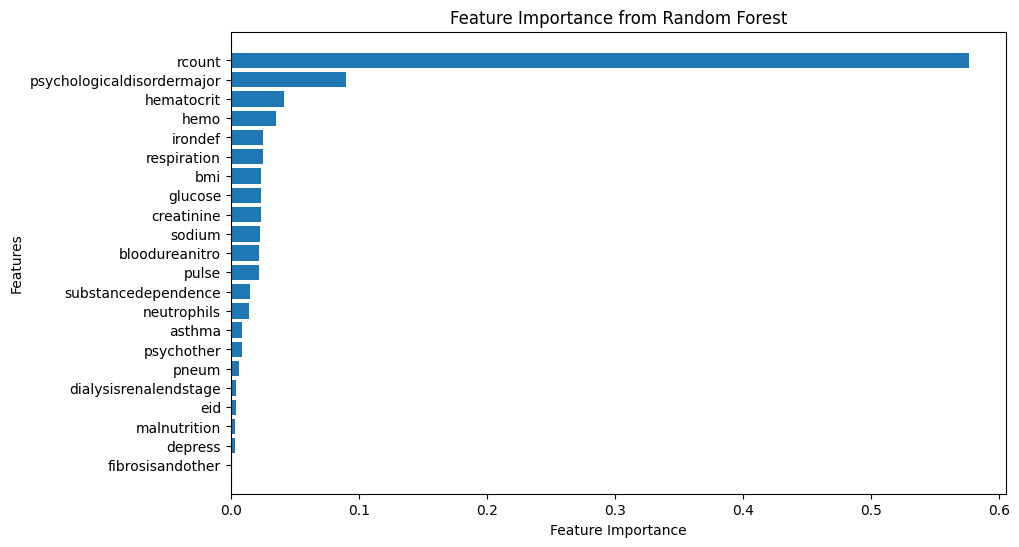

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained RandomForest model
importances = best_model.feature_importances_

# Get feature names
feature_names = X.columns

# Sort features by importance
sorted_indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[sorted_indices], importances[sorted_indices])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()


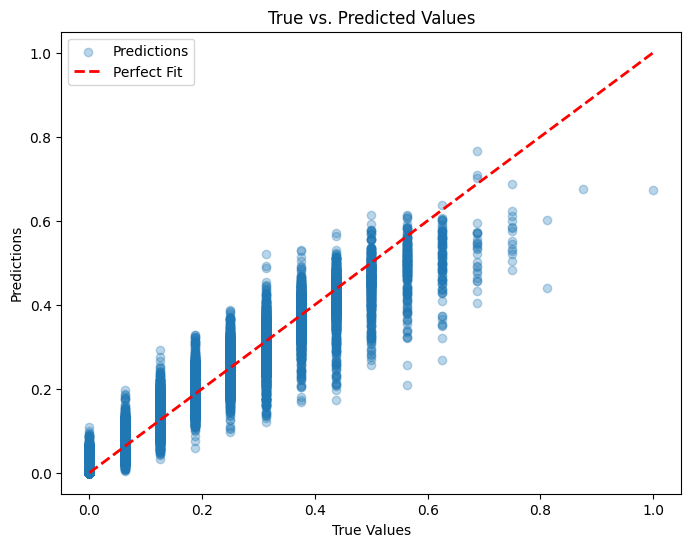

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Fit") 
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs. Predicted Values")
plt.legend()
plt.show()


In [2]:
import joblib

joblib.dump(best_model, "modelF.pkl")


['modelF.pkl']